In [97]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict ,Annotated,Literal
from dotenv import load_dotenv
import os
from pydantic import BaseModel ,Field 
import operator
    

In [98]:
load_dotenv()

True

In [99]:
api_key = os.getenv('GOOGLE_API_KEY')

In [100]:
import google.generativeai as genai
genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))
models = genai.list_models()

for m in models:
    print(m.name, "->", m.supported_generation_methods)

models/gemini-2.5-flash -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-pro -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-001 -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-exp-image-generation -> ['generateContent', 'countTokens', 'bidiGenerateContent']
models/gemini-2.0-flash-lite-001 -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite -> ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-flash-preview-tts -> ['countTokens', 'generateContent']
models/gemini-2.5-pro-preview-tts -> ['countTokens', 'generateContent', 'batchGenerateContent']
models/gemma-3-1b-it -> ['generateContent', 'countToke

In [101]:
model = ChatGoogleGenerativeAI(
    model='gemini-2.0-flash',
    google_api_key = api_key
)

In [102]:
class SentimentSchema(BaseModel):
    sentiment : Literal['positive','negative'] = Field(description="sentiement of the review")
    

In [103]:
class DiagnosisSchema(BaseModel):
    issue_type : Literal["UX","Performance","Bug","Support","Other"] = Field(description="The category of issue mentioned in the review")
    tone : Literal["angry","Frustrated","Disappointed","Calm"] = Field(description="The emotional tone expressed by the user")
    urgency : Literal["low","mediam","high"] = Field(description="How urgent or critical the issue appears to be")


In [104]:
structure_model = model.with_structured_output(SentimentSchema)
diagnosis_structure_model = model.with_structured_output(DiagnosisSchema)

In [105]:
prompt = "what is the sentiment of the following review - the software is too bad"
structure_model.invoke(prompt)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 54.455182707s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [ ]:
class ReviewState(TypedDict):
    review : str
    sentiment : Literal["positive","negative"]
    diagnosis : dict
    response : str
    

In [ ]:
def find_sentiment(state:ReviewState) -> ReviewState:
    prompt = f"For the following review find out the sentiment \n {state['review']}" 
    sentiment = structure_model.invoke(prompt).sentiment
    return {'sentiment':sentiment}

def check_sentiment(state:ReviewState) -> Literal["positive_response","run_diagnosis"]:
    if state['sentiment'] == "positive":
        return "positive_response"
    else:
        return "run_diagnosis"   

def positive_response(state:ReviewState) ->ReviewState:
    prompt = f"Write a warm thank you message in response to this review \n\n {state['review']}\n\n Also,kindly ask the user to leave feedback on the our websit.Keep the response concise and under 25 words."

    output = model.invoke(prompt).content

    return {'response':output}

def run_diagnosis(state:ReviewState) -> ReviewState:
    prompt = f"Diagnose this negative review : \n\n {state['review']}\n Return issue_type , tone and urgency"

    response = diagnosis_structure_model.invoke(prompt)

    return {'diagnosis':response.model_dump()}

def negative_response(state:ReviewState) -> ReviewState:
    diagnosis = state['diagnosis']
    prompt = f"""
    You are a support assitant.
    The user had a '{diagnosis['issue_type']}' issue , sounded '{diagnosis['tone']}' , and marked urgency as '{diagnosis['urgency']}'

    write an empathetic , helpful resoultion message
"""
    response = model.invoke(prompt).content
    return {'response':response}

In [ ]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment",find_sentiment)
graph.add_node("positive_response",positive_response)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("negative_response",negative_response)

graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_sentiment)
graph.add_edge("positive_response",END)
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("negative_response",END)
workflow = graph.compile()


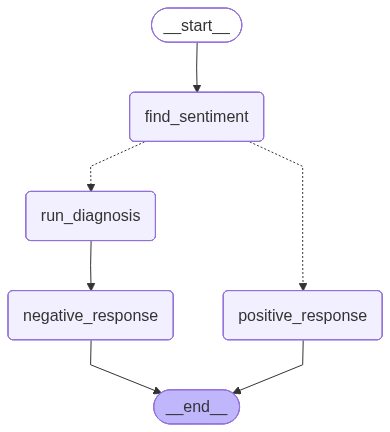

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
inital_state = {'review':"To many ads! Doesn't really do what you think it will and using the camera to take a photo doesn't work at all. You basically just mix and match different images together. Not really worth installing."}

workflow.invoke(inital_state)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 49.071009522s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT